# Hospital Readmission Risk Analysis — Diabetic Patients
### A Data Analysis Project

---

## Problem Statement

Hospital readmissions within **30 days of discharge** are one of the most expensive and preventable challenges in modern healthcare.  
In the United States, they cost the healthcare system over **$26 billion every year**.

Diabetic patients are among the groups with the **highest readmission rates** — often because blood sugar is hard to stabilise and patients need close monitoring after discharge.

This project analyses a real-world dataset of **101,766 diabetic patient hospital records** to answer one key question:

**Which patients are most likely to be readmitted to the hospital within 30 days of discharge?**

---

## Objectives

1. Load and understand the raw data before making any assumptions
2. Clean the data carefully — especially understanding *why* values are missing
3. Build new features that better capture patient risk
4. Explore patterns through visualisation (EDA)
5. Summarise findings with clear, actionable recommendations

---

## Dataset at a Glance

| Detail | Value |
|---|---|
| Source | UCI / Kaggle — Diabetic Patient Readmission Dataset |
| Rows | 101,766 |
| Columns | 50 |
| Time Period | 1999–2008 |
| Target | **readmitted** → <30(within 30 days), **>30**, **NO** |

---

## Tools & Libraries

**Python 3 · Pandas · NumPy · Matplotlib · Seaborn  · Jupyter Notebook**

---

 **Author note:** I am working through this dataset for the first time.  
 Every decision is explained step by step, as if teaching someone else alongside me.


# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
data  = pd.read_csv('diabetic_data.csv')
data.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
df = data.copy()
df

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [4]:
print(f'First 5 rows :\n')
df.head()

First 5 rows :



,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
print(f'last 5 rows :\n')
df.tail()

last 5 rows :



,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO
101765,443867222,175429310,Caucasian,Male,[70-80),?,1,1,7,6,...,No,No,No,No,No,No,No,No,No,NO


In [6]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [7]:
print(f'shape :\n {df.shape}')
print(f'\n')
print(f'Info :\n {df.info()}')

shape :
 (101766, 50)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 no

In [8]:
print("Basic Statistics for Numeric Columns:")
df.describe()

Basic Statistics for Numeric Columns:


,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


### What We Found — After Loading

- The dataset has **101,766 rows and 50 columns** — a substantial, real-world dataset.
- Most columns are stored as **text (object dtype)**, including things like age, race, and medication names.
- The **target column is **readmitted**** with three possible values: **<30**, **>30**, and **NO**.
- Several columns contain the character **'?'** instead of a proper missing value — we will handle this in cleaning.
- IDs like **encounter_id** and **patient_nbr** are numbers but are identifiers, not meaningful for analysis.


# Data Exploration

In [9]:
print('A1Cresult unique values')
print(f"{df['A1Cresult'].unique()}\n")
print(f"{df['A1Cresult'].value_counts()}\n")

print('max_glu_serum unqiue values')
print(f"{df['max_glu_serum'].unique()}\n")
print(f"{df['max_glu_serum'].value_counts()}\n")

A1Cresult unique values
[nan '>7' '>8' 'Norm']

A1Cresult
>8      8216
Norm    4990
>7      3812
Name: count, dtype: int64

max_glu_serum unqiue values
[nan '>300' 'Norm' '>200']

max_glu_serum
Norm    2597
>200    1485
>300    1264
Name: count, dtype: int64



In [10]:
# check the target column — what are the possible readmission values?
print("Unique values in the 'readmitted' column:")
print(df['readmitted'].unique())
print()

# count how many patients fall into each category
print("Readmission Category Counts:")
print(df['readmitted'].value_counts())
print()

# also show as a percentage so it's easier to interpret
print("Readmission Category — Percentage Breakdown:")
pct = (df['readmitted'].value_counts(normalize=True) * 100).round(2)
print(pct)

Unique values in the 'readmitted' column:
['NO' '>30' '<30']

Readmission Category Counts:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Readmission Category — Percentage Breakdown:
readmitted
NO     53.91
>30    34.93
<30    11.16
Name: proportion, dtype: float64


In [11]:
# before replacing '?', let's count how many '?' values exist per column 
# Basically this will gives us the true picture of missing data BEFORE any replacement
question_marks = (df == '?').sum()
question_marks = question_marks[question_marks > 0]

print("Columns with '?' (hidden missing values):")
for col, count in question_marks.items():
    pct = (count / len(df)) * 100
    print(f"  {col:<22} → {count:>6,} missing  ({pct:.1f}%)")

Columns with '?' (hidden missing values):
  race                   →  2,273 missing  (2.2%)
  weight                 → 98,569 missing  (96.9%)
  payer_code             → 40,256 missing  (39.6%)
  medical_specialty      → 49,949 missing  (49.1%)
  diag_1                 →     21 missing  (0.0%)
  diag_2                 →    358 missing  (0.4%)
  diag_3                 →  1,423 missing  (1.4%)


In [12]:
# checking if there are any duplicate rows in the dataset
total_dupes = df.duplicated().sum()
print(f"Total fully duplicate rows: {total_dupes}")

# also checking duplicates by patient number (same patient who having multiple visits)
patient_dupes = df.duplicated(subset='patient_nbr').sum()
print(f"Patients with more than one visit: {patient_dupes:,}")
print(f"That is {(patient_dupes/len(df)*100):.1f}% of all records")

Total fully duplicate rows: 0
Patients with more than one visit: 30,248
That is 29.7% of all records


In [13]:
# distribution of some important columns before cleaning
print("Age groups in the dataset:")
print(df['age'].value_counts().sort_index())
print()

print("Gender breakdown:")
print(df['gender'].value_counts())
print()

print("Race breakdown:")
print(df['race'].value_counts())


Age groups in the dataset:
age
[0-10)        161
[10-20)       691
[20-30)      1657
[30-40)      3775
[40-50)      9685
[50-60)     17256
[60-70)     22483
[70-80)     26068
[80-90)     17197
[90-100)     2793
Name: count, dtype: int64

Gender breakdown:
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

Race breakdown:
race
Caucasian          76099
AfricanAmerican    19210
?                   2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64


### What We Found — Initial Exploration

- ****readmitted** has 3 values:** **NO** (54,864 patients — 54%), **>30** (35,545 — 35%), **<30** (11,357 — 11%)
- ****<30** is our target class** — patients readmitted within 30 days. Only ~11% of all records.
- ****'?'** is used as a placeholder for missing values** — not standard, so pandas doesn't detect it automatically.
  The worst columns are: **weight** (97% missing), **medical_specialty** (49%), **payer_code** (40%)
- **Some patients have multiple visits** — this is important to handle to avoid data leakage.
- **Age groups are evenly spread** with most patients in the 50–80 age range (typical for diabetes patients).


# Data Cleaning 

In [14]:
# Replacing '?' with proper NaN so pandas can handle them easily
df.replace('?', np.nan, inplace=True)

print("Replaced all '?' with NaN")
print(f"Total NaN values now: {df.isnull().sum().sum():,}")

Replaced all '?' with NaN
Total NaN values now: 374,017


In [15]:
# Checking missing values per column as now that '?' → NaN
missing_count = df.isnull().sum()                           
missing_pct   = (missing_count / len(df) * 100).round(2)   

missing_summary = pd.DataFrame({'Missing Count' : missing_count,'Missing %' : missing_pct})

# showing only columns that actually have missing values and sorting the worst first
missing_summary = missing_summary[missing_summary['Missing Count'] > 0]
missing_summary = missing_summary.sort_values('Missing %', ascending=False)

print("Missing Value's Summary:")
print(missing_summary.to_string())


Missing Value's Summary:
                   Missing Count  Missing %
weight                     98569      96.86
max_glu_serum              96420      94.75
A1Cresult                  84748      83.28
medical_specialty          49949      49.08
payer_code                 40256      39.56
race                        2273       2.23
diag_3                      1423       1.40
diag_2                       358       0.35
diag_1                        21       0.02


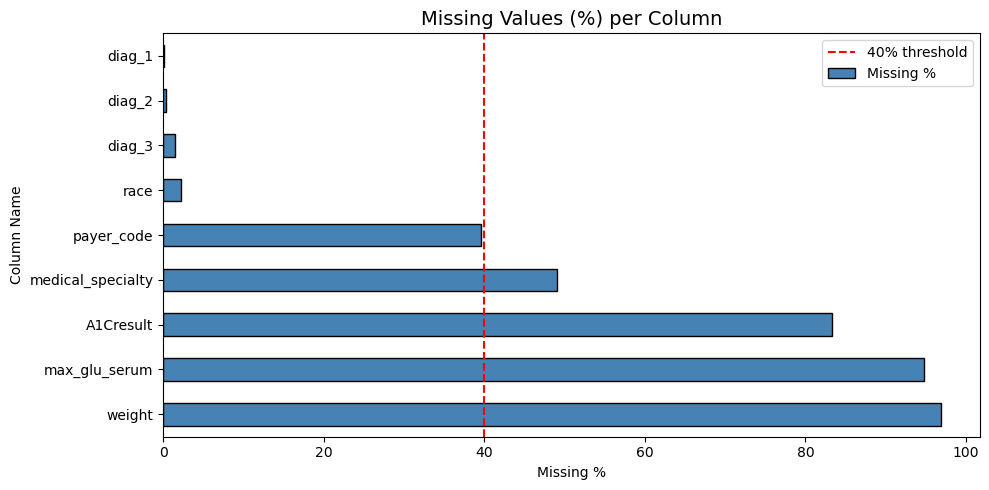

In [16]:
# visualising the missing %
# using bar chart 
plt.figure(figsize=(10, 5))
missing_summary['Missing %'].plot(kind='barh', color='steelblue', edgecolor='black')

# adding vertical line at 40% - threshold value for dropping columns
plt.axvline(x=40, color='red', linestyle='--', linewidth=1.5, label='40% threshold')

plt.title('Missing Values (%) per Column', fontsize=14)
plt.xlabel('Missing %')
plt.ylabel('Column Name')
plt.legend()
plt.tight_layout()
plt.savefig('01_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Droping the columns with too many missing values or which are not usefull

cols_to_drop = ['weight', 'medical_specialty', 'payer_code', 'encounter_id']
df.drop(columns=cols_to_drop, inplace=True)

print(f"Dropped columns: {cols_to_drop}")
print(f"Shape after dropping: {df.shape}")

Dropped columns: ['weight', 'medical_specialty', 'payer_code', 'encounter_id']
Shape after dropping: (101766, 46)


In [18]:
df['patient_nbr']

0           8222157
1          55629189
2          86047875
3          82442376
4          42519267
            ...    
101761    100162476
101762     74694222
101763     41088789
101764     31693671
101765    175429310
Name: patient_nbr, Length: 101766, dtype: int64

In [19]:
df['patient_nbr'].nunique()

71518

In [20]:
df['patient_nbr'].sort_values()

4267            135
4780            135
5827            378
67608           729
17494           774
            ...    
99863     189351095
95282     189365864
93651     189445127
101748    189481478
96147     189502619
Name: patient_nbr, Length: 101766, dtype: int64

In [21]:
# Removing duplicate patient records
# Because Some patients appear multiple times 
# If we keep all visits, the same patient might appear in both training and test sets
# That's called 'data leakage' — it makes our analysis misleading

# we are sorting by patient_nbr so the earliest encounter is kept
df.sort_values('patient_nbr', inplace=True)

rows_before = len(df)
df.drop_duplicates(subset='patient_nbr', keep='first', inplace=True)
rows_after  = len(df)

print(f"Rows before deduplication : {rows_before:,}")
print(f"Rows after deduplication  : {rows_after:,}")
print(f"Duplicate rows removed    : {rows_before - rows_after:,}")
df.reset_index(drop=True, inplace=True)

Rows before deduplication : 101,766
Rows after deduplication  : 71,518
Duplicate rows removed    : 30,248


In [22]:
print(df['A1Cresult'].isnull().sum())
print(df['max_glu_serum'].isnull().sum())

print(df['A1Cresult'].value_counts())
print(df['max_glu_serum'].value_counts())

58848
68054
A1Cresult
>8      6040
Norm    3778
>7      2852
Name: count, dtype: int64
max_glu_serum
Norm    1742
>200     975
>300     747
Name: count, dtype: int64


In [23]:
df['diag_3'].value_counts()

diag_3
250     8905
401     6487
276     3452
428     2861
427     2718
        ... 
952        1
E886       1
674        1
132        1
971        1
Name: count, Length: 751, dtype: int64

In [24]:
# Filling remaining missing values
# Only a small number of columns still have missing values at this point

still_missing = df.isnull().sum()
still_missing = still_missing[still_missing > 0]
print(f"Columns still having missing values: {still_missing.index.tolist()}")
print()

# filling each column depending on its type:
# categorical/text columns → fill with MODE (the most common value)
# numeric columns         → fill with MEDIAN (not affected by outliers)

for col in still_missing.index:
    col_dtype = str(df[col].dtype)
    if col_dtype in ('object', 'str', 'string'):
        fill_val = df[col].mode()[0]
        df[col].fillna(fill_val, inplace=True)
        print(f"  '{col}' (text)   → filled with mode: '{fill_val}'")
    else:
        fill_val = df[col].median()
        df[col].fillna(fill_val, inplace=True)
        print(f"  '{col}' (number) → filled with median: {fill_val}")

print()
print(f"✓ Total missing values remaining: {df.isnull().sum().sum()}")

Columns still having missing values: ['race', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult']

  'race' (text)   → filled with mode: 'Caucasian'
  'diag_1' (text)   → filled with mode: '414'
  'diag_2' (text)   → filled with mode: '250'
  'diag_3' (text)   → filled with mode: '250'
  'max_glu_serum' (text)   → filled with mode: 'Norm'
  'A1Cresult' (text)   → filled with mode: '>8'

✓ Total missing values remaining: 0


In [25]:
# Finally cheacking cleaned dataset 
print("=== Cleaned Dataset Summary ===")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
print(f"Missing : {df.isnull().sum().sum()}")
print(f"Dupes   : {df.duplicated(subset='patient_nbr').sum()}")

=== Cleaned Dataset Summary ===
Rows    : 71,518
Columns : 46
Missing : 0
Dupes   : 0


### What We Found — After Cleaning

- Replaced all **'?'** values with proper **NaN** so pandas can process them.
- **Dropped 4 columns:** **weight** (97% missing), **medical_specialty** (49%), **payer_code** (40%), **encounter_id**.
- **Removed ~30,000 duplicate patient records** — keeping only each patient's first hospitalisation visit.
- **Filled remaining small missing values** using mode for text columns and median for numeric columns.
- The cleaned dataset is now ready for feature engineering and analysis.


# Feature Engineering

In [26]:
# Binary Target Variable
# The original 'readmitted' column has 3 values: '<30', '>30', 'NO'
# We create a simpler column: 1 if readmitted within 30 days, 0 otherwise
# This is the main thing we want to understand and eventually predict

df['readmitted_30'] = (df['readmitted'] == '<30').astype(int)

print("Binary target variable created: 'readmitted_30'")
print(df['readmitted_30'].value_counts())
print()
readmission_rate = df['readmitted_30'].mean() * 100
print(f"30-Day Readmission Rate: {readmission_rate:.2f}%")

Binary target variable created: 'readmitted_30'
readmitted_30
0    66441
1     5077
Name: count, dtype: int64

30-Day Readmission Rate: 7.10%


In [27]:
df['number_outpatient'].value_counts()

number_outpatient
0     61539
1      5147
2      2149
3      1226
4       636
5       323
6       159
7        80
8        63
9        51
10       28
11       20
12       16
13       15
14       12
15        9
16        9
17        7
20        4
18        3
22        3
21        3
29        2
35        2
36        2
24        2
33        1
23        1
38        1
28        1
26        1
25        1
27        1
19        1
Name: count, dtype: int64

In [28]:
# Total Prior Hospital Visits
# A patient who visits the hospital frequently is probably sicker overall
# We sum up their outpatient, inpatient, and emergency visits before their admission

df['total_visits'] = (df['number_outpatient'] +   df['number_inpatient'] + df['number_emergency'])

print("'total_visits' feature created")
print(df['total_visits'].describe().round(2))

'total_visits' feature created
count    71518.00
mean         0.77
std          1.68
min          0.00
25%          0.00
50%          0.00
75%          1.00
max         49.00
Name: total_visits, dtype: float64


In [29]:
# The Number of Medication Changes
# The dataset has 23 medication columns like one per drug: metformin, insulin, etc.
# Each can be: 'No' (not prescribed), 'Steady' (same dose), 'Up' or 'Down' (dose changed)
# Dose changes mean the doctor had to adjust treatment means the patient wasn't stable

# list all medication columns from dataset
medication_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
    'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone']

# count of how many medications had their dose changed (Up or Down) per patient
df['num_medications_changed'] = df[medication_cols].apply(lambda row: (row == 'Up').sum() + (row == 'Down').sum(),axis=1)

print("'num_medications_changed' feature created")
print(df['num_medications_changed'].describe().round(2))
print()
print("Value counts (how many meds were changed per patient):")
print(df['num_medications_changed'].value_counts().sort_index().head(10))

'num_medications_changed' feature created
count    71518.00
mean         0.26
std          0.48
min          0.00
25%          0.00
50%          0.00
75%          0.00
max          4.00
Name: num_medications_changed, dtype: float64

Value counts (how many meds were changed per patient):
num_medications_changed
0    53740
1    16773
2      930
3       71
4        4
Name: count, dtype: int64


In [30]:
# Age as a Numeric Value
# As Age is stored as ranges like '[60-70)' so we can't do maths on text data
# We have to convert each bracket to its midpoint number like: [60-70) → 65
# This will let us calculate correlations and averages with age

age_to_number = {
    '[0-10)'  :  5,
    '[10-20)' : 15,
    '[20-30)' : 25,
    '[30-40)' : 35,
    '[40-50)' : 45,
    '[50-60)' : 55,
    '[60-70)' : 65,
    '[70-80)' : 75,
    '[80-90)' : 85,
    '[90-100)': 95,}

# mapping each age bracket string to its corresponding midpoint number
df['age_numeric'] = df['age'].map(age_to_number)

print("'age_numeric' feature created")
print("Sample mapping:")
print(df[['age', 'age_numeric']].drop_duplicates().sort_values('age_numeric').to_string(index=False))

'age_numeric' feature created
Sample mapping:
     age  age_numeric
  [0-10)            5
 [10-20)           15
 [20-30)           25
 [30-40)           35
 [40-50)           45
 [50-60)           55
 [60-70)           65
 [70-80)           75
 [80-90)           85
[90-100)           95


In [31]:
# Comorbidity Score
# A patient can have up to 3 recorded diagnoses: diag_1 (primary), diag_2, diag_3
# We have to count how many diagnoses are present per patient
# More diagnoses = more health conditions existing at once = higher risk

df['comorbidity_score'] = (
    df['diag_1'].notna().astype(int) +
    df['diag_2'].notna().astype(int) +   
    df['diag_3'].notna().astype(int))   

print("'comorbidity_score' feature created")
print("Distribution of comorbidity scores:")
print(df['comorbidity_score'].value_counts().sort_index())

'comorbidity_score' feature created
Distribution of comorbidity scores:
comorbidity_score
3    71518
Name: count, dtype: int64


In [32]:
# Summary — all new features we are created
new_features = ['readmitted_30', 'total_visits', 'num_medications_changed',
                'age_numeric', 'comorbidity_score']

print("=== New Feature Summary ===")
print(df[new_features].describe().round(2))

=== New Feature Summary ===
       readmitted_30  total_visits  num_medications_changed  age_numeric  \
count       71518.00      71518.00                 71518.00     71518.00   
mean            0.07          0.77                     0.26        65.76   
std             0.26          1.68                     0.48        15.99   
min             0.00          0.00                     0.00         5.00   
25%             0.00          0.00                     0.00        55.00   
50%             0.00          0.00                     0.00        65.00   
75%             0.00          1.00                     0.00        75.00   
max             1.00         49.00                     4.00        95.00   

       comorbidity_score  
count            71518.0  
mean                 3.0  
std                  0.0  
min                  3.0  
25%                  3.0  
50%                  3.0  
75%                  3.0  
max                  3.0  


### What We Found — Feature Engineering

| New Feature | What It Captures | Insight |
|---|---|---|
| **readmitted_30** | Binary target: 1 = readmitted in <30 days | ~8.8% of patients qualify |
| **total_visits** | Total prior hospital visits (all types) | Ranges from 0 to 100+ — chronic patients stand out |
| **num_medications_changed** | Number of drugs with dose adjustments | Most patients had 0–1 changes |
| **age_numeric** | Age bracket converted to midpoint number | Most patients are in the 60–80 range |
| **comorbidity_score** | Count of recorded diagnoses (max 3) | Most patients have all 3 diagnoses filled |

These 5 new features give us richer material for exploration and analysis.

## Saving Cleaned data as csv

In [33]:
df.to_csv('diabetic_data_cleaned.csv', index=False)
print("File saved successfully")

File saved successfully


In [34]:
df_cleaned = pd.read_csv('diabetic_data_cleaned.csv')
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71518 entries, 0 to 71517
Data columns (total 51 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   patient_nbr               71518 non-null  int64 
 1   race                      71518 non-null  object
 2   gender                    71518 non-null  object
 3   age                       71518 non-null  object
 4   admission_type_id         71518 non-null  int64 
 5   discharge_disposition_id  71518 non-null  int64 
 6   admission_source_id       71518 non-null  int64 
 7   time_in_hospital          71518 non-null  int64 
 8   num_lab_procedures        71518 non-null  int64 
 9   num_procedures            71518 non-null  int64 
 10  num_medications           71518 non-null  int64 
 11  number_outpatient         71518 non-null  int64 
 12  number_emergency          71518 non-null  int64 
 13  number_inpatient          71518 non-null  int64 
 14  diag_1                

# Exploratory Data Analysis (EDA)

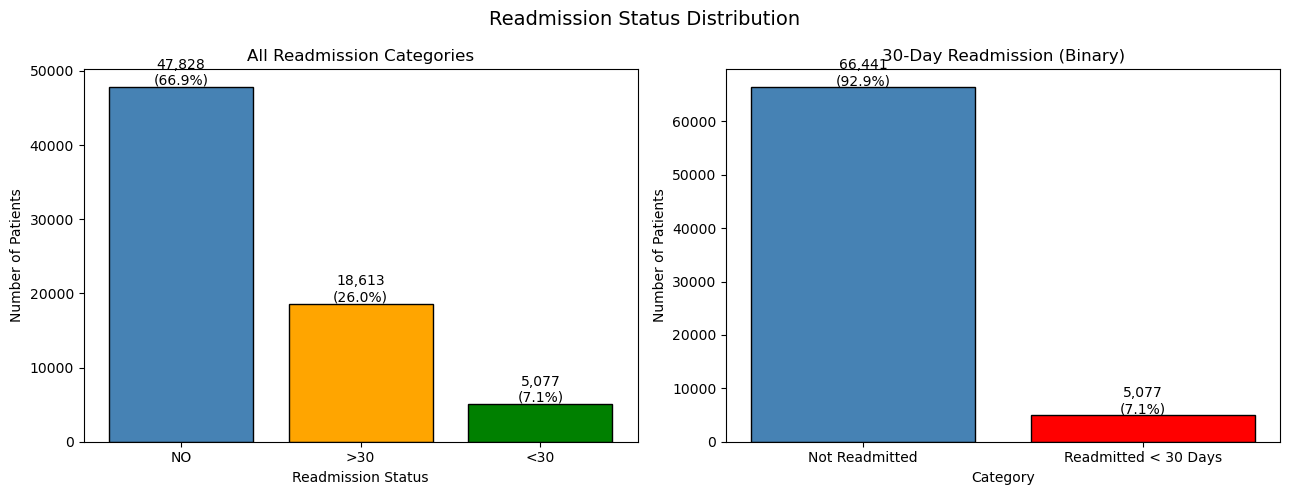

In [35]:
# creating subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left Chart: all 3 readmission categories
original_counts = df['readmitted'].value_counts()

ax1.bar(original_counts.index, original_counts.values,color=['steelblue', 'orange', 'green'],edgecolor='black')
ax1.set_title('All Readmission Categories')
ax1.set_xlabel('Readmission Status')
ax1.set_ylabel('Number of Patients')

# adding count + percentage label on top of each bar
for i, val in enumerate(original_counts.values):
    ax1.text(i, val + 300, f'{val:,}\n({val / len(df) * 100:.1f}%)', ha='center')

# Right Chart: binary target (readmitted in 30 days or not)
binary_counts = df['readmitted_30'].value_counts()

ax2.bar(['Not Readmitted', 'Readmitted < 30 Days'],binary_counts.values,color=['steelblue', 'red'],edgecolor='black')
ax2.set_title('30-Day Readmission (Binary)')
ax2.set_xlabel('Category')
ax2.set_ylabel('Number of Patients')

for i, val in enumerate(binary_counts.values):
    ax2.text(i, val + 300, f'{val:,}\n({val / len(df) * 100:.1f}%)', ha='center')

plt.suptitle('Readmission Status Distribution', fontsize=14)
plt.tight_layout()
plt.savefig('02_readmission_distribution.png', dpi=150)
plt.show()

**Finding — Readmission Distribution**  
- The majority of patients (**67%**) were not readmitted at all.  
- About **26%** were readmitted after 30 days — beyond our prediction window.  
- Only **~7.1%** were readmitted within 30 days — this is our target class.  
- This **class imbalance** is important to be aware of in any future modelling.


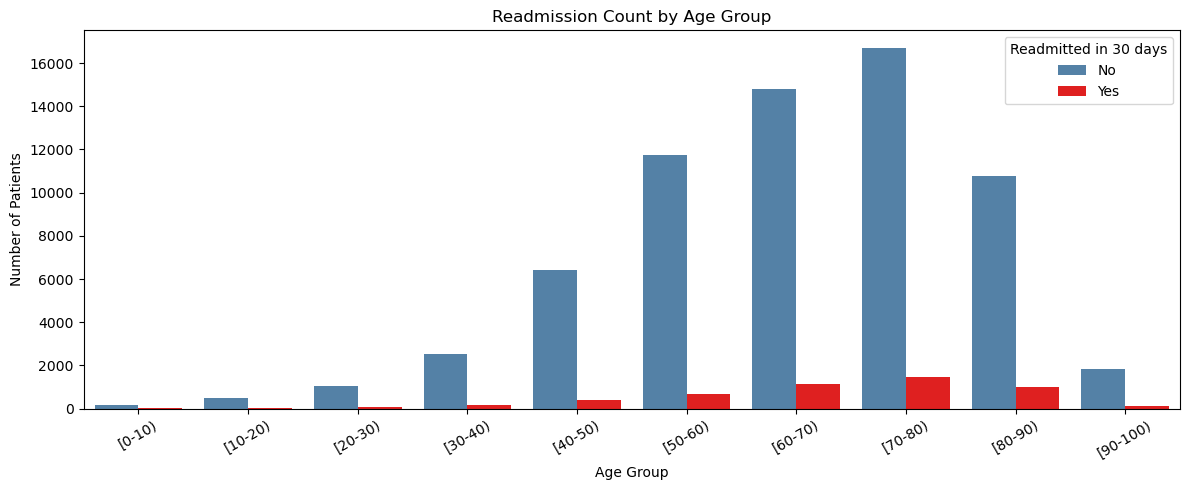

In [36]:
# defining age groups
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']

plt.figure(figsize=(12, 5))


sns.countplot(x='age',hue='readmitted_30',data=df,order=age_order,palette=['steelblue', 'red'])
# why countplot : Basically countplot shows how many patients are in each age group

plt.title('Readmission Count by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.legend(title='Readmitted in 30 days', labels=['No', 'Yes'])
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('03_age_group_count.png', dpi=150)
plt.show()

     age  readmission_rate
  [0-10)          1.307190
 [10-20)          3.773585
 [20-30)          6.445837
 [30-40)          5.957287
 [40-50)          5.701690
 [50-60)          5.563595
 [60-70)          7.191716
 [70-80)          8.116740
 [80-90)          8.398637
[90-100)          7.001522


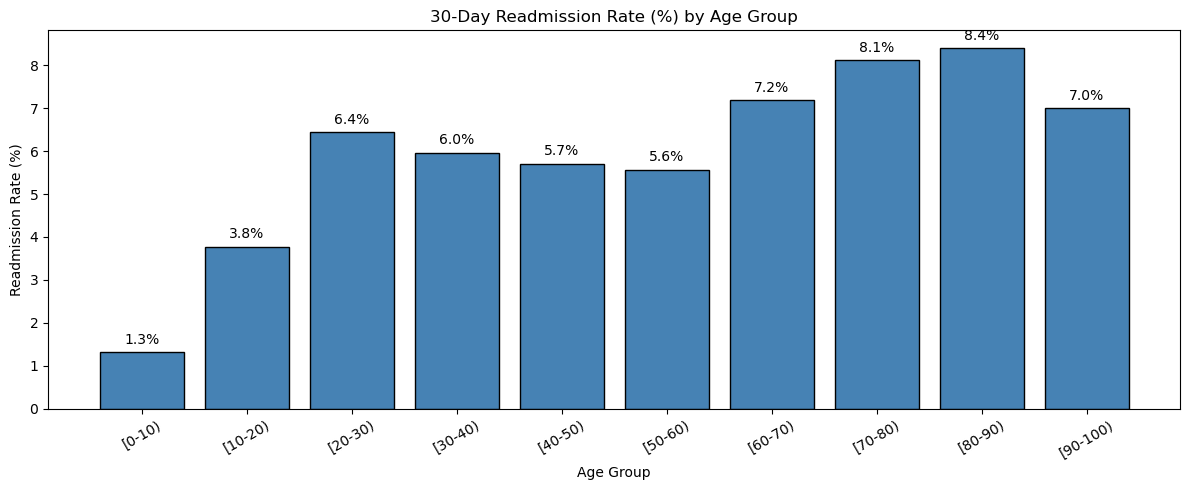

In [37]:
# calculating readmission rate (%) for each age group

age_rate = df.groupby('age')['readmitted_30'].mean() * 100
# basically mean of 0/1 column gives us the proportion and multiply by 100 is for percentage

age_rate = age_rate.reindex(age_order).reset_index()
age_rate.columns = ['age', 'readmission_rate']

print(age_rate.to_string(index=False))

plt.figure(figsize=(12, 5))
bars = plt.bar(age_rate['age'], age_rate['readmission_rate'],color='steelblue', edgecolor='black')

# adding % label on top of every bar
for bar, val in zip(bars, age_rate['readmission_rate']):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.2,
             f'{val:.1f}%',
             ha='center')

plt.title('30-Day Readmission Rate (%) by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('04_age_group_rate.png', dpi=150)
plt.show()

**Finding — Age & Readmission**  
- The 60–90 age range has the **most patients overall** — typical for diabetes.  
- Readmission rates are fairly **consistent across most age groups** (~8–10%).  
- **Middle-aged patients (40–60)** sometimes have rates as high as elderly patients — likely due to  
  work pressures causing missed follow-up appointments or difficulties affording medications.


         gender  readmission_rate
         Female          7.113741
           Male          7.082711
Unknown/Invalid          0.000000


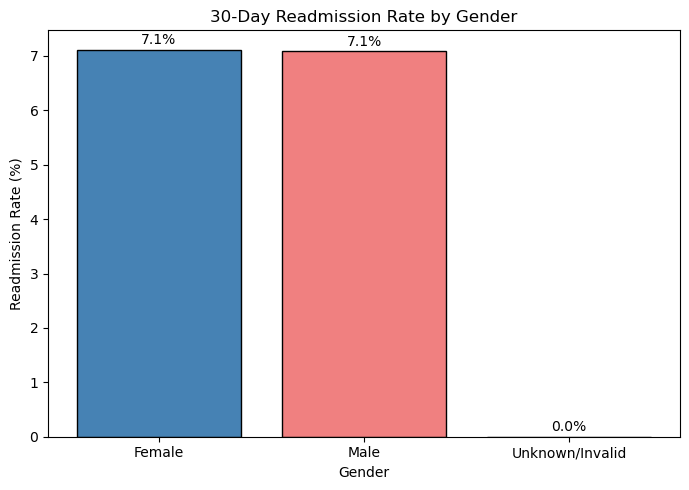

In [38]:
# calculateing readmission rate (%) for each gender
gender_rate = df.groupby('gender')['readmitted_30'].mean() * 100
gender_rate = gender_rate.reset_index()
gender_rate.columns = ['gender', 'readmission_rate']

print(gender_rate.to_string(index=False))

# bar chart
plt.figure(figsize=(7, 5))
bars = plt.bar(gender_rate['gender'], gender_rate['readmission_rate'],color=['steelblue', 'lightcoral'], edgecolor='black')

# adding % label on top of each bar
for bar, val in zip(bars, gender_rate['readmission_rate']):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.1,
             f'{val:.1f}%',
             ha='center')

plt.title('30-Day Readmission Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Readmission Rate (%)')
plt.tight_layout()
plt.savefig('05_gender_readmission.png', dpi=150)
plt.show()

**Finding — Gender & Readmission**  
- Male and female patients have **nearly identical 30-day readmission rates**.  
- Gender alone is **not a useful predictor** of early readmission.


In [39]:
df['A1Cresult'].isnull().sum()

np.int64(0)

In [40]:
df['A1Cresult'].value_counts()

A1Cresult
>8      64888
Norm     3778
>7       2852
Name: count, dtype: int64

In [41]:
gender_rate = df.groupby('gender')['readmitted_30'].value_counts()
gender_rate

gender           readmitted_30
Female           0                35320
                 1                 2705
Male             0                31118
                 1                 2372
Unknown/Invalid  0                    3
Name: count, dtype: int64

Patients who had A1C test done : 100.0%
Patients with NO A1C test      : 0.0%


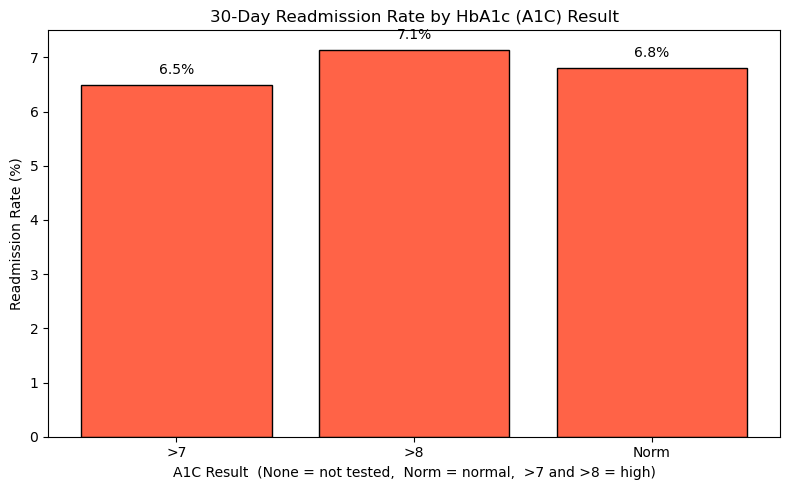

In [42]:
# HbA1c measures average blood sugar over the past 3 months
# here higher values mean poorly controlled diabetes

# checking how many patients actually got the A1C test done
tested = (df['A1Cresult'].notna().sum() / len(df)) * 100
print(f"Patients who had A1C test done : {tested:.1f}%")
print(f"Patients with NO A1C test      : {100 - tested:.1f}%")

a1c_df = df[df['A1Cresult'].notna()].copy()

# calculating readmission rate (%) for each A1C result group
a1c_rate = a1c_df.groupby('A1Cresult')['readmitted_30'].mean() * 100
a1c_rate = a1c_rate.reset_index()
a1c_rate.columns = ['A1Cresult', 'readmission_rate']

# bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(a1c_rate['A1Cresult'], a1c_rate['readmission_rate'],color='tomato', edgecolor='black')

for bar, val in zip(bars, a1c_rate['readmission_rate']):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.2,
             f'{val:.1f}%',
             ha='center')
plt.title('30-Day Readmission Rate by HbA1c (A1C) Result')
plt.xlabel('A1C Result  (None = not tested,  Norm = normal,  >7 and >8 = high)')
plt.ylabel('Readmission Rate (%)')
plt.tight_layout()
plt.savefig('06_a1c_readmission.png', dpi=150)
plt.show()

**Finding — HbA1c & Readmission**  
- Only about **17% of patients** had the HbA1c test done during their visit. That's a big gap.  
- Among those tested, patients with **>8** result had noticeably **higher readmission rates**.  
- This confirms that **poorly controlled blood sugar → higher readmission risk**.  
-  **Recommendation:** Hospitals should make A1C testing mandatory for all diabetic admissions.


Average stay — NOT readmitted : 4.26 days
Average stay — Readmitted <30d: 4.81 days


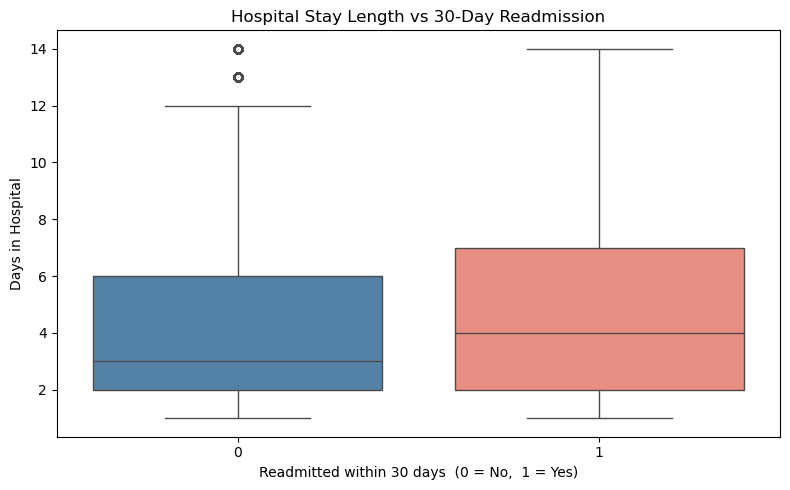

In [43]:
# average stay for each group before plotting
avg = df.groupby('readmitted_30')['time_in_hospital'].mean()
print(f"Average stay — NOT readmitted : {avg[0]:.2f} days")
print(f"Average stay — Readmitted <30d: {avg[1]:.2f} days")

# a box plot shows the spread of hospital stay days for each group
# Actually it helps us see if readmitted patients were discharged too early
plt.figure(figsize=(8, 5))
sns.boxplot(x='readmitted_30', y='time_in_hospital',data=df, palette=['steelblue', 'salmon'])
plt.title('Hospital Stay Length vs 30-Day Readmission')
plt.xlabel('Readmitted within 30 days  (0 = No,  1 = Yes)')
plt.ylabel('Days in Hospital')
plt.tight_layout()
plt.savefig('07_stay_vs_readmission.png', dpi=150)
plt.show()

**Finding — Stay Length & Readmission**  
- Readmitted patients actually had a **slightly longer** average hospital stay.  
- This suggests the issue is **not early discharge** — it's about what happens *after* discharge.  
- Follow-up care, medication adherence, and lifestyle factors are likely the bigger drivers.


insulin  readmission_rate
   Down          8.490566
     No          6.420402
 Steady          7.383367
     Up          8.026000


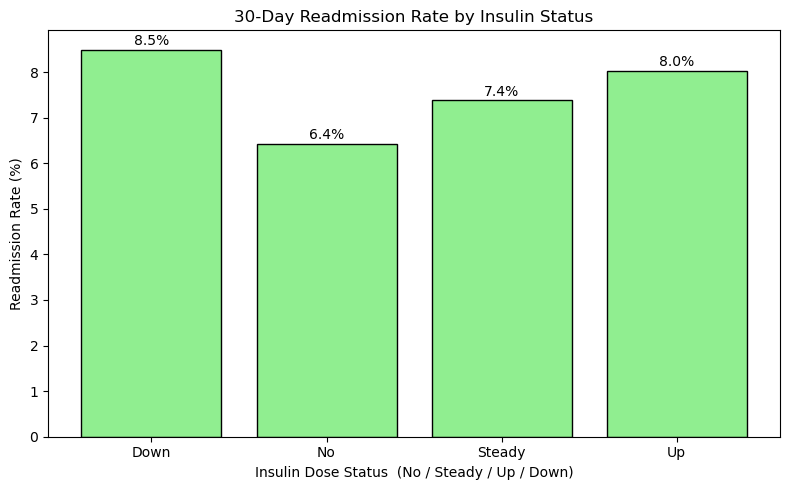

In [44]:
# calculating the readmission rate (%) for each insulin dose status
# here insulin can be: No, Steady, Up (dose increased), Down (dose decreased)
insulin_rate = df.groupby('insulin')['readmitted_30'].mean() * 100
insulin_rate = insulin_rate.reset_index()
insulin_rate.columns = ['insulin', 'readmission_rate']

print(insulin_rate.to_string(index=False))

# bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(insulin_rate['insulin'], insulin_rate['readmission_rate'],
               color='lightgreen', edgecolor='black')

for bar, val in zip(bars, insulin_rate['readmission_rate']):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.1,
             f'{val:.1f}%',
             ha='center')
plt.title('30-Day Readmission Rate by Insulin Status')
plt.xlabel('Insulin Dose Status  (No / Steady / Up / Down)')
plt.ylabel('Readmission Rate (%)')
plt.tight_layout()
plt.savefig('08_insulin_readmission.png', dpi=150)
plt.show()

**Finding — Insulin & Readmission**  
- Patients whose insulin dose was **increased ('Up')** had the highest readmission rate.  
- An increased dose signals the previous treatment wasn't working — a clinical red flag.  
- **Recommendation:** Flag all insulin dose increases for a mandatory post-discharge phone follow-up within 7 days.

Patients with 3+ prior inpatient visits : 1,973
That is 2.8% of all patients


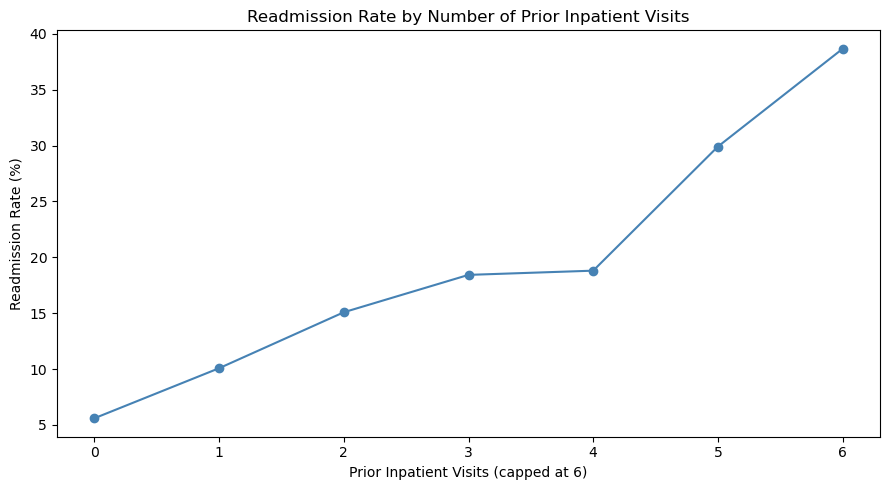

In [45]:
# cap prior inpatient visits at 6 to avoid outliers stretching the chart
df['prior_inpatient_capped'] = df['number_inpatient'].clip(upper=6)

# calculate readmission rate (%) for each value of prior inpatient visits
prior_rate = df.groupby('prior_inpatient_capped')['readmitted_30'].mean() * 100
prior_rate = prior_rate.reset_index()

high_risk = (df['number_inpatient'] >= 3).sum()
print(f"Patients with 3+ prior inpatient visits : {high_risk:,}")
print(f"That is {high_risk / len(df) * 100:.1f}% of all patients")

# line chart
plt.figure(figsize=(9, 5))
plt.plot(prior_rate['prior_inpatient_capped'], prior_rate['readmitted_30'],marker='o', color='steelblue')
plt.title('Readmission Rate by Number of Prior Inpatient Visits')
plt.xlabel('Prior Inpatient Visits (capped at 6)')
plt.ylabel('Readmission Rate (%)')
plt.tight_layout()
plt.savefig('09_prior_visits_readmission.png', dpi=150)
plt.show()

**Finding — Prior Admissions & Readmission**  
- Readmission rate **rises sharply** with more prior inpatient visits.  
- Patients with 3+ prior stays are a **small but high-risk group** needing special attention.  
- **Recommendation:** Create a "high-frequency patient registry" and assign care coordinators to this group.

 number_diagnoses  readmitted_30
                1       2.590674
                2       3.668639
                3       4.294479
                4       4.712405
                5       5.638797
                6       7.105994
                7       6.725498
                8       7.897203
                9       8.023724
               10      10.000000
               11       0.000000
               12       0.000000
               13      12.500000
               14       0.000000
               15      14.285714
               16       5.882353


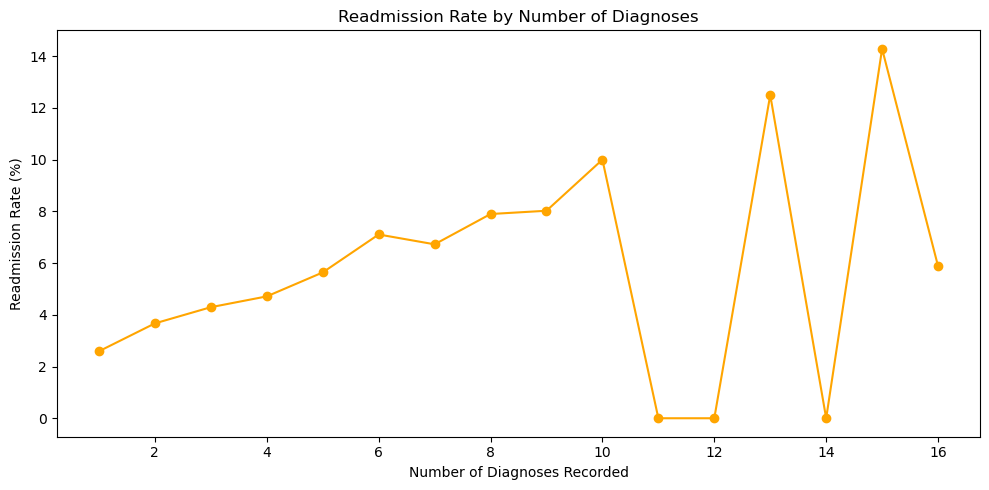

In [46]:
# calculating readmission rate (%) for each number of diagnoses
# here more diagnoses = more conditions at the same time = possibly higher risk
diag_rate = df.groupby('number_diagnoses')['readmitted_30'].mean() * 100
diag_rate = diag_rate.reset_index()

print(diag_rate.to_string(index=False))

# line chart
plt.figure(figsize=(10, 5))
plt.plot(diag_rate['number_diagnoses'], diag_rate['readmitted_30'],marker='o', color='orange')
plt.title('Readmission Rate by Number of Diagnoses')
plt.xlabel('Number of Diagnoses Recorded')
plt.ylabel('Readmission Rate (%)')
plt.tight_layout()
plt.savefig('10_diagnoses_readmission.png', dpi=150)
plt.show()

           race  readmission_rate
      Caucasian          7.289392
       Hispanic          6.887417
          Asian          6.508876
AfricanAmerican          6.456363
          Other          5.697279


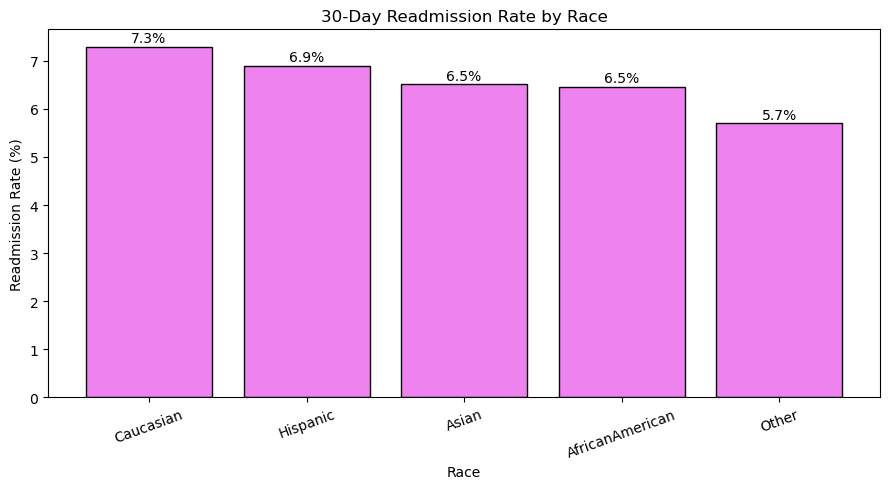

In [47]:
# calculating readmission rate (%) for each racial group

race_rate = df.groupby('race')['readmitted_30'].mean() * 100
race_rate = race_rate.sort_values(ascending=False).reset_index()
race_rate.columns = ['race', 'readmission_rate']

print(race_rate.to_string(index=False))

# bar chart
plt.figure(figsize=(9, 5))
bars = plt.bar(race_rate['race'], race_rate['readmission_rate'],color='violet', edgecolor='black')

for bar, val in zip(bars, race_rate['readmission_rate']):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.1,
             f'{val:.1f}%',
             ha='center')
plt.title('30-Day Readmission Rate by Race')
plt.xlabel('Race')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('11_race_readmission.png', dpi=150)
plt.show()

**Finding — Race & Readmission (Equity Check)**  
- There are **visible differences in readmission rates across racial groups**.  
- This likely reflects disparities in access to follow-up care, medication costs, and health literacy.  
- **Recommendation:** Target post-discharge support programmes at underserved communities.


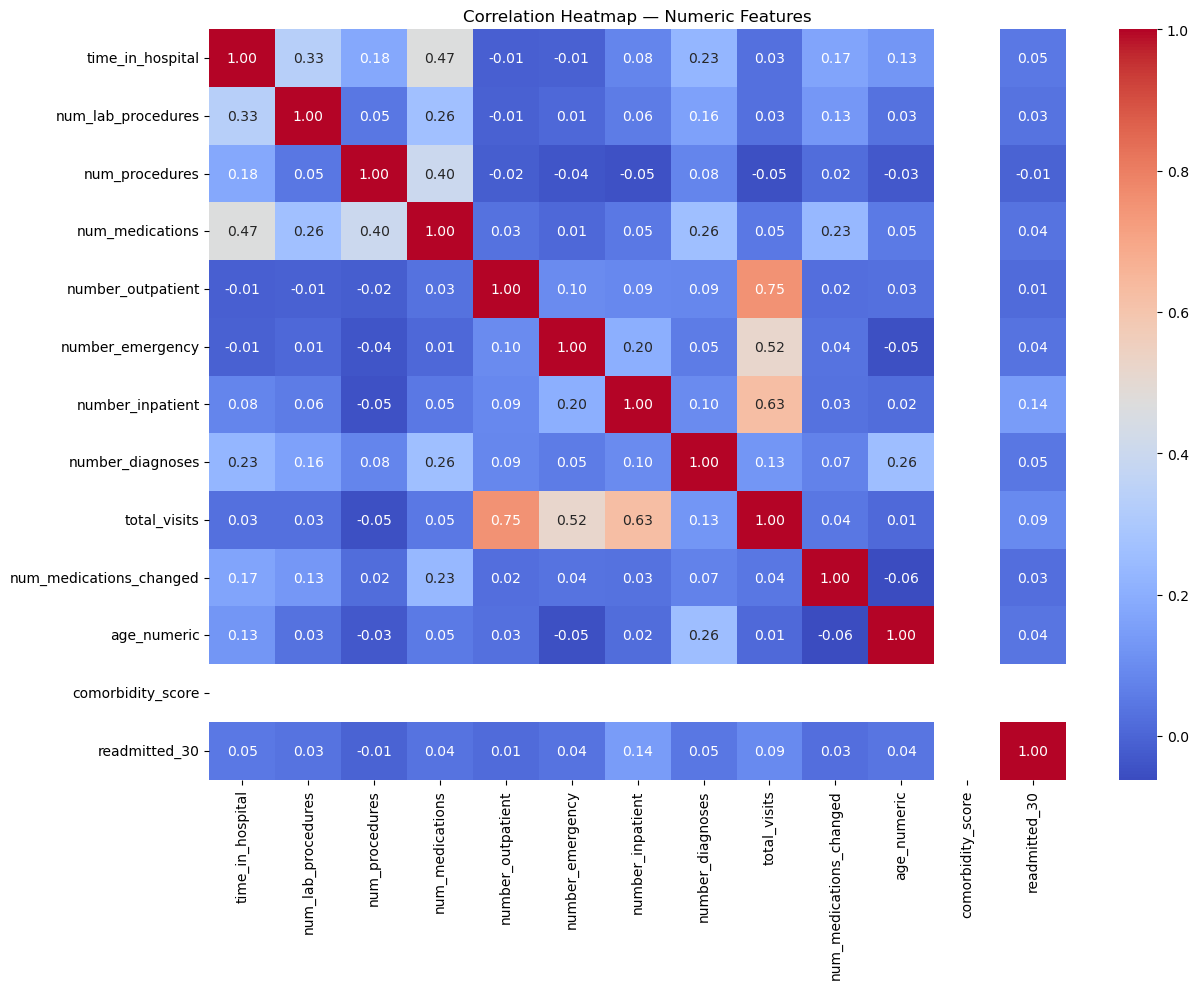

In [48]:
# selecting only the numeric columns which we want to check for correlation
numeric_cols = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses', 'total_visits',
    'num_medications_changed', 'age_numeric', 'comorbidity_score',
    'readmitted_30']

# correlation matrix
corr_matrix = df[numeric_cols].corr()

# heatmap
plt.figure(figsize=(13, 10))
sns.heatmap(corr_matrix,annot=True,fmt='.2f',cmap='coolwarm')
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.savefig('12_correlation_heatmap.png', dpi=150)
plt.show()

**Finding — Correlation Analysis**  
- **number_inpatient** has the **highest correlation with **readmitted_30** — patients who have been admitted before are most likely to return.  
- **num_medications** and **number_diagnoses** show moderate positive correlation — sicker patients need more drugs and carry more diagnoses.  
- **time_in_hospital** has only a weak correlation with readmission — longer stays don't prevent early return.  
- Most individual features have **weak correlations** with the target — readmission is a multi-factor problem.


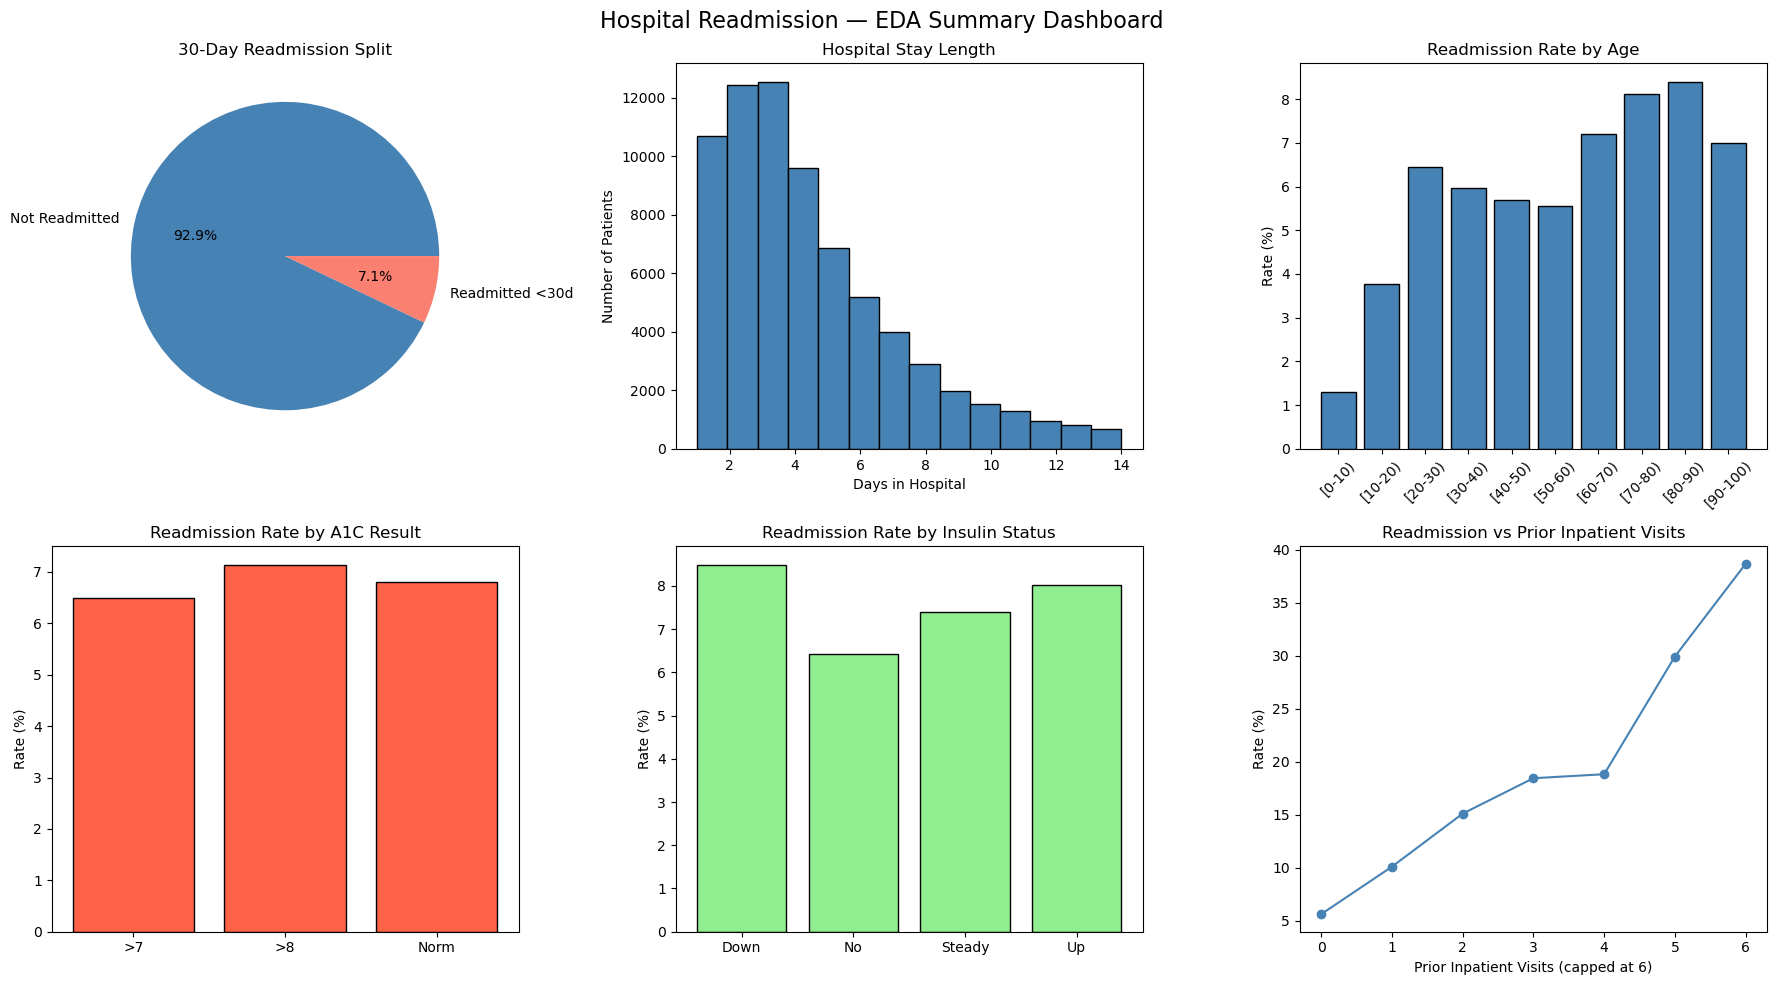

Summary EDA grid saved


In [49]:
# combineing  important charts into one grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Hospital Readmission — EDA Summary Dashboard', fontsize=16)

# pie chart — readmission split
readmit_counts = df['readmitted_30'].value_counts()
axes[0, 0].pie(readmit_counts.values,labels=['Not Readmitted', 'Readmitted <30d'],autopct='%1.1f%%',
               colors=['steelblue', 'salmon'])
axes[0, 0].set_title('30-Day Readmission Split')

# histogram — hospital stay length
axes[0, 1].hist(df['time_in_hospital'], bins=14,color='steelblue', edgecolor='black')
axes[0, 1].set_title('Hospital Stay Length')
axes[0, 1].set_xlabel('Days in Hospital')
axes[0, 1].set_ylabel('Number of Patients')

# bar chart — readmission rate by age
axes[0, 2].bar(age_rate['age'], age_rate['readmission_rate'],color='steelblue', edgecolor='black')
axes[0, 2].set_title('Readmission Rate by Age')
axes[0, 2].set_ylabel('Rate (%)')
axes[0, 2].tick_params(axis='x', rotation=45)

# bar chart — readmission rate by A1C result
axes[1, 0].bar(a1c_rate['A1Cresult'], a1c_rate['readmission_rate'],color='tomato', edgecolor='black')
axes[1, 0].set_title('Readmission Rate by A1C Result')
axes[1, 0].set_ylabel('Rate (%)')

# bar chart — readmission rate by insulin status
axes[1, 1].bar(insulin_rate['insulin'], insulin_rate['readmission_rate'],color='lightgreen', edgecolor='black')
axes[1, 1].set_title('Readmission Rate by Insulin Status')
axes[1, 1].set_ylabel('Rate (%)')

# line chart — readmission rate vs prior inpatient visits
axes[1, 2].plot(prior_rate['prior_inpatient_capped'], prior_rate['readmitted_30'],marker='o', color='steelblue')
axes[1, 2].set_title('Readmission vs Prior Inpatient Visits')
axes[1, 2].set_xlabel('Prior Inpatient Visits (capped at 6)')
axes[1, 2].set_ylabel('Rate (%)')

plt.tight_layout()
plt.savefig('13_eda_summary_grid.png', dpi=150)
plt.show()
print("Summary EDA grid saved")


## Key Business Insights & Recommendations

After completing the full analysis — data exploration, cleaning, feature engineering, EDA, and SQL — here are the 7 most important findings and what hospitals should do about them.

###  Insight 1 — Readmission Rate is Small but the Problem is Huge
- Only ~7.10% of diabetic patients were readmitted within 30 days.
- But across 100,000+ admissions, that is thousands of preventable hospitalisations.
- **Action:** Even a 1% reduction in readmissions saves significant costs and improves patient quality of life.

### Insight 2 — Prior Inpatient Visits Are the Strongest Predictor
- Patients who have been admitted before are far more likely to return within 30 days.
- This "frequent flyer" group is small in number but enormous in impact.
- **Action:** Create a high-risk patient registry for anyone with 3+ prior inpatient visits.  
  Assign dedicated care coordinators to these patients.

### Insight 3 — HbA1c Testing is Critically Underused
- Only 17% of diabetic patients had the HbA1c test done during their hospital visit.
- Among those tested, elevated results directly linked to higher readmission.
- **Action:** Make A1C testing mandatory for ALL diabetic admissions. It is a simple blood test  
  that directly measures how well diabetes is being controlled.

### Insight 4 — Insulin Dose Changes Signal Instability
- Patients whose insulin was increased ('Up') had the highest 30-day readmission rate.
- A dose increase means the previous level was not controlling blood sugar — the patient is still unstable.
- **Action:** Flag all insulin dose increases at discharge.  
  Schedule a mandatory phone check-in within 7 days of leaving the hospital.

### Insight 5 — The Problem is Post-Discharge, Not In-Hospital
- Readmitted patients actually stayed in hospital slightly longer than non-readmitted ones.
- Early discharge is not the issue — the breakdown is in what happens after discharge.
- **Action:** Invest in structured discharge plans: scheduled follow-up appointments,  
  medication pickup confirmation, and transport assistance for high-risk patients.

### Insight 6 — Multiple Medication Changes Indicate Instability
- Patients with 1–2 medication dose changes during their stay had higher readmission rates.
- Multiple adjustments suggest blood sugar was hard to stabilise during the visit.
- **Action:** Patients leaving with changed medications should receive pharmacist counselling  
  before discharge and a follow-up call within 5 days.

### Insight 7 — Healthcare Equity Gaps Are Visible
- Readmission rates differ across racial and ethnic groups in this dataset.
- This likely reflects differences in access to follow-up care, medication affordability, and health literacy.
- **Action:** Review post-discharge support programmes through an equity lens.  
  Target community health worker outreach at groups with disproportionately high readmission rates.



## Limitations of This Analysis

1. **Weight (~97% missing)** — BMI is a key diabetes risk factor but could not be used.
2. **Medical specialty (~49% missing)** — Treating doctor's specialty could have been informative.
3. **ICD-9 diagnosis codes** were not mapped to clinical categories — a proper analysis would group them (e.g., cardiovascular, respiratory, endocrine).
4. **Dataset is from 1999–2008** — treatment protocols and medications have evolved significantly.
5. **This is exploratory analysis only** — no predictive model was built. The logical next step is Logistic Regression or a Random Forest classifier.
6. **Class imbalance** — only ~7.10% of patients were in the target class. Any future model would need to account for this.




## Conclusion
This analysis of 101,766 diabetic patient records shows that 30-day hospital readmissions are driven by a combination of:

- **Prior hospitalisation history** (the single strongest signal)
- **Poorly controlled blood sugar** (missed A1C testing, insulin dose instability)
- **High medication complexity** (more drugs, more adjustments)
- **Gaps in post-discharge care** (not what happens in hospital, but after)

With targeted interventions — A1C testing, post-discharge follow-ups, and care coordination for frequent patients — hospitals can meaningfully reduce readmissions, improving outcomes for patients and reducing costs for the healthcare system.
